In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, balanced_accuracy_score


# ── 1. Load data ─────────────────────────────────────────────────
df_bind = pd.read_excel('../data/single_metal_atoms_on_graphene_binding_energy_and_diffusion_barrier.xlsx')
df_bind_g = df_bind.groupby('Metal')[['Binding', 'Diffusion']].mean().reset_index()

df_aff = pd.read_excel("../data/supported_metal_M_oxygen_affinity_QMO_and_support_metal_affinity_QMM_prime.xlsx")
df_aff = df_aff.rename(columns={df_aff.columns[1]: 'QMO'})

df_nps = pd.read_excel('./NPs.xlsx')
df_nps = df_nps.rename(columns={'反应后MOF表面是否有纳米粒子': 'ExternalNP'})
df_nps['MOF'] = df_nps['MOF'].ffill()

# Define your renaming dictionary
mof_rename_dict = {
}

# Apply the replacement
df_nps["MOF"] = df_nps["MOF"].replace(mof_rename_dict)

df_mof = pd.read_csv('../data/MOF_factor.csv').reset_index(drop = True)
# Optional: check for consistency with df_mof
for i in df_nps["MOF"]:
    assert i in list(df_mof["MOF"]), f"{i} not in df_mof"
# ── 2. Merge all descriptors ─────────────────────────────────────
df = (
    df_nps
    .merge(df_mof, on='MOF', how='left')
    .merge(df_bind_g.rename(columns={'Binding': 'BindingEnergy', 'Diffusion': 'DiffusionBarrier'}),
           left_on='M', right_on='Metal', how='left')
    .merge(df_aff[['Metal', 'QMO']], left_on='M', right_on='Metal', how='left')
    .drop(columns=['Metal', 'Metal_aff'], errors='ignore')
)

df = df.dropna(subset=['BindingEnergy', 'DiffusionBarrier', 'QMO'])
df = df.drop(columns=['Metal_x', 'Metal_y'], errors='ignore')

noble_set = {'Au', 'Ag', 'Pt', 'Pd', 'Ir', 'Rh', 'Ru'}
df['Noble'] = df['M'].apply(lambda x: 1 if x in noble_set else 0)

core_feats = ['BindingEnergy','DiffusionBarrier','QMO','Noble']
extra_feats = [f"Factor{i}" for i in range(1, 46)]

features_all = core_feats + extra_feats

# Drop rows with missing values
df = df.dropna(subset=features_all + ['ExternalNP'])

X = df[features_all].copy()
y = df['ExternalNP'].astype(int).copy()

# ── 2. Train & evaluate logistic ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state = 43))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")

# Re-fit on full dataset
pipeline.fit(X, y)

predict_y = pipeline.predict(X)
print(abs(y - predict_y).sum())

# ── 2. Train & evaluate MLP (8-4) ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=100000, random_state=42, tol = 1e-6, activation="tanh"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=500000, random_state=42, tol = 1e-6, activation="tanh"))
])
# Re-fit on full dataset
pipeline.fit(X, y)

predict_y = pipeline.predict(X) 
print(abs(y - predict_y).sum())

5-fold Accuracy: 0.818 ± 0.081
5-fold Balanced Accuracy: 0.817 ± 0.076
14
5-fold Accuracy: 0.782 ± 0.067
5-fold Balanced Accuracy: 0.776 ± 0.070
0


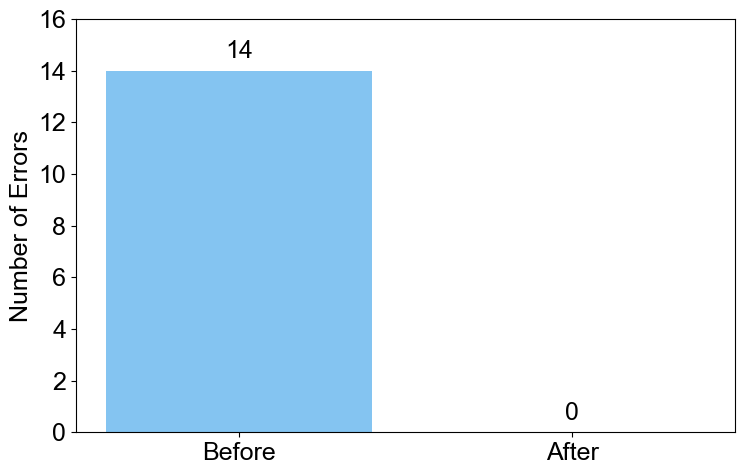

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

errors = [14, 0]
labels = ['Before', 'After']

with plt.rc_context({
    "font.family": "Arial",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 18
}):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Set bar colors here
    bars = ax.bar(labels, errors,
                  color=['#84c4f1',  # red for "Before"
                         '#84c4f1']) # green for "After"
    # Add value labels on top of bars
    for bar, val in zip(bars, errors):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.3,
            f'{val}',
            ha='center', va='bottom'
        )

    ax.set_ylabel('Number of Errors')
    ax.set_ylim(0, 16)  # leave a bit of headroom above 14

    plt.tight_layout()
    plt.savefig('./error_decrease_14_to_0.png', dpi=600, bbox_inches='tight')
    plt.show()

<Figure size 800x500 with 0 Axes>

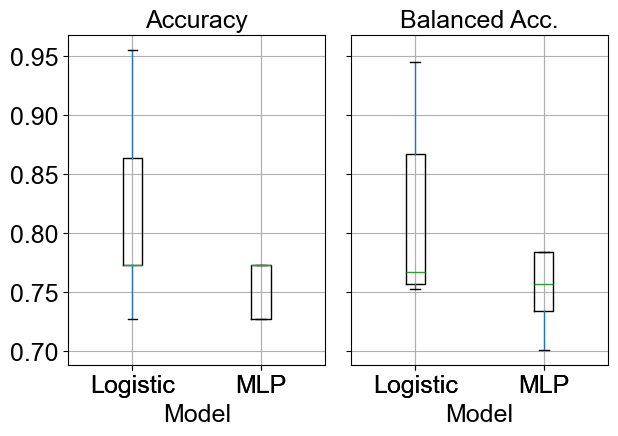


Cross-validated performance (5-fold):
Logistic:
  Accuracy       = 0.818 ± 0.091
  Balanced Acc.  = 0.817 ± 0.085
MLP:
  Accuracy       = 0.782 ± 0.075
  Balanced Acc.  = 0.776 ± 0.079


C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_9100\1539244887.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = metrics_df.groupby('Model')[['Accuracy', 'Balanced Acc.']].agg(['mean', 'std'])


In [3]:
# ── 3. Compare Logistic vs MLP with boxplots over CV folds ──────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, balanced_accuracy_score
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the two models (unfitted; cross_val_score will clone & fit them)
logistic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=43))
])

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10, 4),
                          max_iter=100000,
                          random_state=42,
                          tol=1e-6,
                          activation="tanh"))
])

models = {
    'Logistic': logistic_pipe,
    'MLP': mlp_pipe,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = []
for name, model in models.items():
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    bal_scores = cross_val_score(
        model, X, y, cv=cv,
        scoring=make_scorer(balanced_accuracy_score)
    )
    for fold, (acc, bal) in enumerate(zip(acc_scores, bal_scores)):
        metrics.append({
            'Model': name,
            'Fold': fold,
            'Accuracy': acc,
            'Balanced Acc.': bal
        })

metrics_df = pd.DataFrame(metrics)

# ── Plot boxplots ───────────────────────────────────────────────
order = ['Logistic', 'MLP']
metrics_df['Model'] = pd.Categorical(
    metrics_df['Model'],
    categories=order,
    ordered=True
)

boxprops   = dict(linewidth=1)
flierprops = dict(marker='o', markersize=4, markerfacecolor='none')

with plt.rc_context({
    "font.family": "Arial",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 18
}):
    fig = plt.figure(figsize=(8, 5))

    metrics_df.boxplot(
        by='Model',
        column=['Accuracy', 'Balanced Acc.'],
        boxprops=boxprops,
        flierprops=flierprops,
        showfliers=False
    )

    plt.ylabel('Score')
    plt.suptitle('')
    plt.tight_layout()
    plt.savefig("./logistic_vs_mlp_acc_boxplot.png",
                dpi=600, bbox_inches='tight')
    plt.show()

# ── Print numeric metrics summary ───────────────────────────────
summary = metrics_df.groupby('Model')[['Accuracy', 'Balanced Acc.']].agg(['mean', 'std'])

print("\nCross-validated performance (5-fold):")
for model in summary.index:
    acc_mean = summary.loc[model, ('Accuracy', 'mean')]
    acc_std  = summary.loc[model, ('Accuracy', 'std')]
    bal_mean = summary.loc[model, ('Balanced Acc.', 'mean')]
    bal_std  = summary.loc[model, ('Balanced Acc.', 'std')]
    print(f"{model}:")
    print(f"  Accuracy       = {acc_mean:.3f} ± {acc_std:.3f}")
    print(f"  Balanced Acc.  = {bal_mean:.3f} ± {bal_std:.3f}")


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, balanced_accuracy_score


# ── 1. Load data ─────────────────────────────────────────────────
df_bind = pd.read_excel('../data/single_metal_atoms_on_graphene_binding_energy_and_diffusion_barrier.xlsx')
df_bind_g = df_bind.groupby('Metal')[['Binding', 'Diffusion']].mean().reset_index()

df_aff = pd.read_excel("../data/supported_metal_M_oxygen_affinity_QMO_and_support_metal_affinity_QMM_prime.xlsx")
df_aff = df_aff.rename(columns={df_aff.columns[1]: 'QMO'})

df_nps = pd.read_excel('./NPs.xlsx')
df_nps = df_nps.rename(columns={'反应后MOF表面是否有纳米粒子': 'ExternalNP'})
df_nps['MOF'] = df_nps['MOF'].ffill()

# Define your renaming dictionary
mof_rename_dict = {
}

# Apply the replacement
df_nps["MOF"] = df_nps["MOF"].replace(mof_rename_dict)

df_mof = pd.read_csv('../data/MOF_factor.csv').reset_index(drop = True)
# Optional: check for consistency with df_mof
for i in df_nps["MOF"]:
    assert i in list(df_mof["MOF"]), f"{i} not in df_mof"
# ── 2. Merge all descriptors ─────────────────────────────────────
df = (
    df_nps
    .merge(df_mof, on='MOF', how='left')
    .merge(df_bind_g.rename(columns={'Binding': 'BindingEnergy', 'Diffusion': 'DiffusionBarrier'}),
           left_on='M', right_on='Metal', how='left')
    .merge(df_aff[['Metal', 'QMO']], left_on='M', right_on='Metal', how='left')
    .drop(columns=['Metal', 'Metal_aff'], errors='ignore')
)

df = df.dropna(subset=['BindingEnergy', 'DiffusionBarrier', 'QMO'])
df = df.drop(columns=['Metal_x', 'Metal_y'], errors='ignore')

noble_set = {'Au', 'Ag', 'Pt', 'Pd', 'Ir', 'Rh', 'Ru'}
df['Noble'] = df['M'].apply(lambda x: 1 if x in noble_set else 0)

core_feats = ['BindingEnergy','DiffusionBarrier','QMO','Noble']

features_all = core_feats

# Drop rows with missing values
df = df.dropna(subset=features_all + ['ExternalNP'])

X = df[features_all].copy()
y = df['ExternalNP'].astype(int).copy()

# ── 2. Train & evaluate logistic ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state = 43))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")

# Re-fit on full dataset
pipeline.fit(X, y)

predict_y = pipeline.predict(X)
print(abs(y - predict_y).sum())

# ── 2. Train & evaluate MLP (8-4) ────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=100000, random_state=42, tol = 1e-6))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
bal_acc_scores = cross_val_score(
    pipeline, X, y, cv=cv,
    scoring=make_scorer(balanced_accuracy_score)
)

print(f"5-fold Accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print(f"5-fold Balanced Accuracy: {bal_acc_scores.mean():.3f} ± {bal_acc_scores.std():.3f}")


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(10,4), max_iter=100000, random_state=42, tol = 1e-6))
])
# Re-fit on full dataset
pipeline.fit(X, y)

predict_y = pipeline.predict(X)
print(abs(y - predict_y).sum())

5-fold Accuracy: 0.864 ± 0.076
5-fold Balanced Accuracy: 0.856 ± 0.079
15
5-fold Accuracy: 0.845 ± 0.062
5-fold Balanced Accuracy: 0.846 ± 0.060
14


In [5]:
X

,BindingEnergy,DiffusionBarrier,QMO,Noble
0,-2.103890,0.120000,-9.796,1
1,-1.870790,0.092100,-4.793,1
2,-1.066000,0.040000,-7.540,1
3,-2.031000,0.100000,-9.445,1
4,-1.965500,0.125500,-6.419,1
...,...,...,...,...
105,-0.462070,0.008675,-3.115,1
106,-0.528203,0.023061,-3.714,1
107,-1.263750,0.060000,-6.961,0
108,-0.570640,0.013910,-6.881,0


In [6]:
y

0      1
1      1
2      1
3      0
4      1
      ..
105    1
106    1
107    0
108    0
109    0
Name: ExternalNP, Length: 110, dtype: int64

In [7]:
(110-14)/110

0.8727272727272727

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── 1. build / reload your merged dataframe df first ──
# (df must contain columns: MOF, M, ExternalNP)

# ── 2. pivot to MOF × Metal grid ─────────────────────
heat = df.pivot_table(index='MOF',
                      columns='M',
                      values='ExternalNP',
                      aggfunc='first')

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

cmap = ListedColormap(['blue', 'red'])         # 0 → blue, 1 → red
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

im = ax.imshow(heat.values, cmap=cmap, norm=norm, aspect='auto')

# Tick labels
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

# ── add gridlines ───────────────────────────────────
ax.set_xticks(np.arange(-.5, len(heat.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(heat.index),   1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=1.0)
ax.tick_params(which='minor', bottom=False, left=False)   # hide minor tick marks

# Color‑bar & title
cbar = fig.colorbar(im, ax=ax, label='ExternalNP  (blue: inside, red: outside)')
ax.set_title('External NP presence by MOF and Metal')

plt.tight_layout()
plt.show()